In [1]:
import pandas as pd

In [2]:
sales_df = pd.read_csv(r'C:\Users\sumit\DATA_SCIENCE\THE DEVELOPER ARENA INTERNSHIP\Week 7\sales_data.csv')
display(sales_df.head())

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
# Display the first 5 rows of the DataFrame
display(sales_df.head())

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
# Display concise summary of the DataFrame
display(sales_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


None

In [5]:
# Calculate and display descriptive statistics for numerical columns
display(sales_df.describe())

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [7]:
import scipy.stats as stats
import statsmodels.formula.api as smf

In [8]:
# Hypothesis Test 1: One-way ANOVA for Total_Sales across Regions
# Group Total_Sales by Region
regions = sales_df['Region'].unique()
regional_sales = [sales_df['Total_Sales'][sales_df['Region'] == r] for r in regions]

# Perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(*regional_sales)

print(f"Hypothesis Test 1: One-way ANOVA for Total_Sales across Regions")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in Total_Sales across different regions (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant difference in Total_Sales across different regions (p >= 0.05).")

Hypothesis Test 1: One-way ANOVA for Total_Sales across Regions
F-statistic: 2.16
P-value: 0.097
Conclusion: There is no statistically significant difference in Total_Sales across different regions (p >= 0.05).


In [9]:
# Hypothesis Test 2: Independent samples t-test for Total_Sales between two products (e.g., Phone vs. Laptop)
phone_sales = sales_df[sales_df['Product'] == 'Phone']['Total_Sales']
laptop_sales = sales_df[sales_df['Product'] == 'Laptop']['Total_Sales']

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(phone_sales, laptop_sales)

print(f"\nHypothesis Test 2: Independent samples t-test for Total_Sales (Phone vs. Laptop)")
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in Total_Sales between Phones and Laptops (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant difference in Total_Sales between Phones and Laptops (p >= 0.05).")


Hypothesis Test 2: Independent samples t-test for Total_Sales (Phone vs. Laptop)
T-statistic: -0.56
P-value: 0.578
Conclusion: There is no statistically significant difference in Total_Sales between Phones and Laptops (p >= 0.05).


In [10]:
# Hypothesis Test 3: Chi-square test for independence between Product and Region
contingency_table = pd.crosstab(sales_df['Product'], sales_df['Region'])

# Perform chi-square test
chi2, p_value, _, _ = stats.chi2_contingency(contingency_table)

print(f"\nHypothesis Test 3: Chi-square test for independence between Product and Region")
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant relationship between Product and Region (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant relationship between Product and Region (p >= 0.05).")


Hypothesis Test 3: Chi-square test for independence between Product and Region
Chi-square statistic: 14.59
P-value: 0.264
Conclusion: There is no statistically significant relationship between Product and Region (p >= 0.05).


In [11]:
# Correlation Analysis
# Calculate the correlation matrix for numerical columns
correlation_matrix = sales_df[['Quantity', 'Price', 'Total_Sales']].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Quantity,Price,Total_Sales
Quantity,1.000000,0.008014,0.688107
Price,0.008014,1.000000,0.646131
Total_Sales,0.688107,0.646131,1.000000


In [12]:
# Calculate Confidence Intervals
# Confidence Interval for the mean of Total_Sales
mean_total_sales = sales_df['Total_Sales'].mean()
std_err_total_sales = stats.sem(sales_df['Total_Sales'])
confidence_interval_total_sales = stats.norm.interval(
    0.95, loc=mean_total_sales, scale=std_err_total_sales
)

print(f"\n95% Confidence Interval for Mean Total_Sales: {confidence_interval_total_sales[0]:.2f} to {confidence_interval_total_sales[1]:.2f}")


95% Confidence Interval for Mean Total_Sales: 104019.27 to 143281.69


In [13]:
# Perform Regression Analysis
# Multiple Linear Regression: Total_Sales as dependent variable, Quantity and Price as independent variables
model = smf.ols('Total_Sales ~ Quantity + Price', data=sales_df).fit()

print("\nRegression Analysis (Total_Sales ~ Quantity + Price):")
display(model.summary())


Regression Analysis (Total_Sales ~ Quantity + Price):


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Total_Sales   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     369.3
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           4.40e-46
Time:                        10:34:37   Log-Likelihood:                -1185.2
No. Observations:                 100   AIC:                             2376.
Df Residuals:                      97   BIC:                             2384.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.217e+05   9668.294    -12.586      0.000   -1.41e+05   -1.02e+05
Quantity    2.643e+04   1338.869     19.741      0.000    2.38e+04    2.91e+04
Price          4.6106      0.249     18.518      0.000       4.116       5.105
==============================================================================
Omnibus:                        1.152   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.562   Jarque-Bera (JB):                1.077
Skew:                           0.086   Prob(JB):                        0.584
Kurtosis:                       2.522   Cond. No.                     8.25e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.25e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

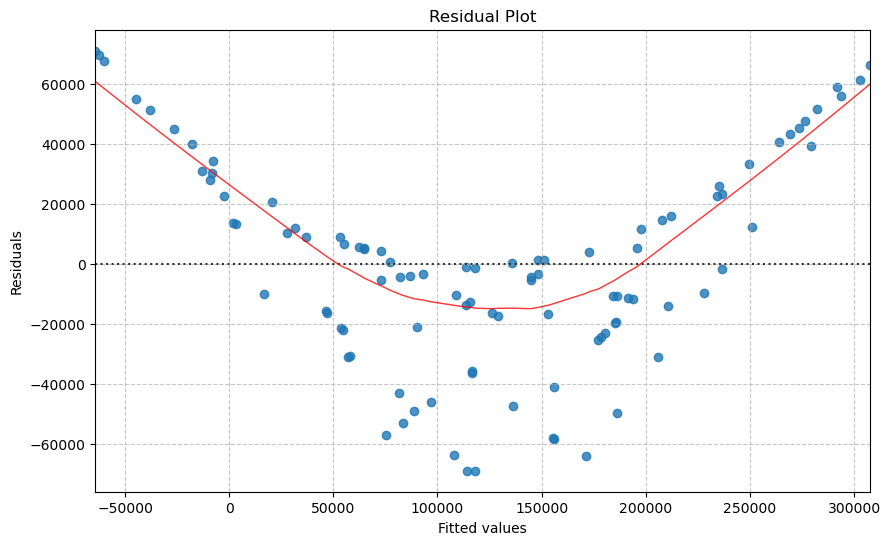

In [15]:
# Create a residual plot
fig = plt.figure(figsize=(10, 6))
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True,
              line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

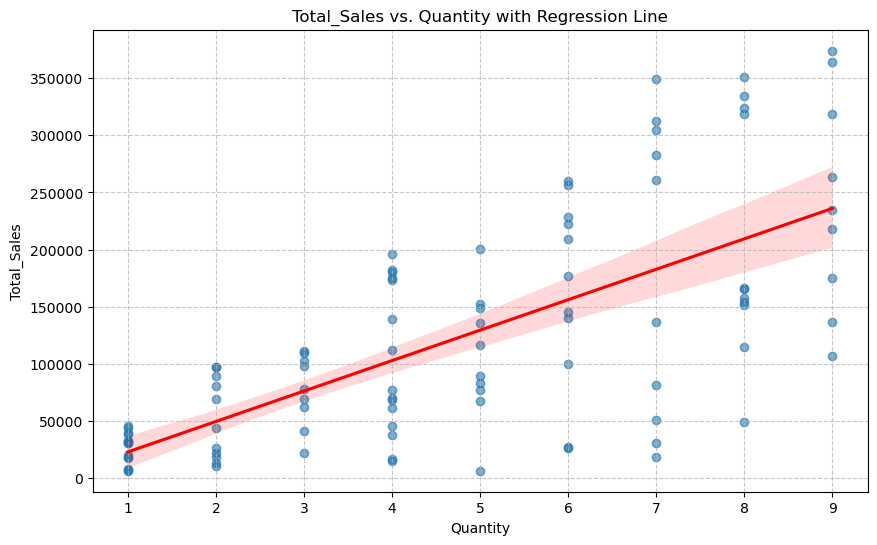

In [17]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Quantity', y='Total_Sales', data=sales_df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Total_Sales vs. Quantity with Regression Line')
plt.xlabel('Quantity')
plt.ylabel('Total_Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()